#### Import

In [2]:
import numpy as np; import pandas as pd; import matplotlib.pyplot as mp; import seaborn as sea; import datetime as dt; import random as r; import math as m; import statistics as st; import mysql.connector as ms; import warnings; warnings.filterwarnings("ignore"); warnings.filterwarnings("ignore", message="pandas only supports SQLAlchemy connectable*"); warnings.filterwarnings("ignore", message=".*is_categorical_dtype is deprecated.*"); warnings.filterwarnings("ignore", message="invalid escape sequence.*", category=SyntaxWarning)


#### Data

In [3]:
dbd="layoffs"


#### Display

In [4]:
# from PIL import Image
# import matplotlib.pyplot as mp

# image_1 = Image.open(r"Image\Image 1.png")
# image_2 = Image.open(r"Image\Image 2.png")
# # image_3 = Image.open(r"Image\Image 3.png")

# images = [image_1, image_2]
# cols = 2
# rows = 2
# mp.figure(figsize=(10, 7),dpi=200)
# mp.subplots_adjust(wspace=0.1, hspace=0)

# for i, img in enumerate(images):
#     ax = mp.subplot(rows, cols, i + 1)
#     rotated = img.rotate(0)
#     ax.imshow(rotated, interpolation="nearest")
#     ax.set_xticks([])
#     ax.set_yticks([])
#     for spine in ax.spines.values():
#         spine.set_visible(True)
#         spine.set_color("black")
#         spine.set_linewidth(2)
#     ax.set_title(f"Page {i+1}",color="red")
# mp.show()

#### Views

In [5]:
db = ms.connect(
    host="localhost",
    user="root",
    password="67777777",
    database=dbd)
cur = db.cursor()
cur.execute("SHOW TABLES")
tables = [t[0] for t in cur.fetchall()]
for table in tables:
    print(f"\n===== {table} =====\n")
    df = pd.read_sql(f"SELECT * FROM {table}", con=db)
    print(" ,\n".join(df.columns))


===== layoffs =====

company ,
location ,
total_laid_off ,
date ,
percentage_laid_off ,
industry ,
source ,
stage ,
funds_raised ,
country ,
date_added ,
location_isnull ,
total_laid_off_isnull ,
percentage_laid_off_isnull ,
industry_isnull ,
source_isnull ,
stage_isnull ,
funds_raised_isnull ,
country_isnull

===== layoffss =====

com ,
loc ,
tlo ,
dat ,
plo ,
ind ,
sou ,
sta ,
fra ,
cou ,
dad ,
loc_in ,
tlo_in ,
plo_in ,
ind_in ,
sou_in ,
sta_in ,
fra_in ,
cou_in


#### Columns

In [6]:
db = ms.connect(host = "localhost", 
                username = "root", 
                password = "67777777", 
                database = dbd) 
cur = db.cursor()
cur.execute("SHOW TABLES");tables=[t[0] for t in cur.fetchall()];dfs=[];import pandas as pd
for i,table in enumerate(tables,1):
 df=pd.read_sql(f"SELECT * FROM {table}",con=db)
 for col in df.columns:
  if 'date'in col.lower()or'time'in col.lower():df[col]=pd.to_datetime(df[col],errors='coerce')
 temp=pd.DataFrame({'Table':table,'Column':df.columns,'Type':[str(df[c].dtype)for c in df.columns]});temp.index=[i]*len(temp);temp.index.name='index';dfs+=[temp,pd.DataFrame([['','','']],columns=temp.columns,index=[""])]
cn_final=pd.concat(dfs);print(f"\n{'':<8}{'Table':<20}{'Column':30}{'Type'}\n")
for i,table in enumerate(tables,1):
 for _,r in cn_final[cn_final['Table']==table].iterrows():print(f"{i:<5}{r['Table']:<18}{r['Column']:<35}{r['Type']}")
 print()
print("All tables in the database:\n"); 
for table in tables: print(f"{table}")


        Table               Column                        Type

1    layoffs           company                            str
1    layoffs           location                           str
1    layoffs           total_laid_off                     float64
1    layoffs           date                               datetime64[us]
1    layoffs           percentage_laid_off                float64
1    layoffs           industry                           str
1    layoffs           source                             str
1    layoffs           stage                              str
1    layoffs           funds_raised                       float64
1    layoffs           country                            str
1    layoffs           date_added                         datetime64[us]
1    layoffs           location_isnull                    int64
1    layoffs           total_laid_off_isnull              int64
1    layoffs           percentage_laid_off_isnull         int64
1    layoffs           indu

#### Table

In [7]:
table="layoffs"
try:display(pd.read_sql(f"select * from {table}", db).pipe(lambda df: df.rename(columns=lambda c: f"{c} (c{df.columns.get_loc(c)+1})").head(2).style.hide(axis="index").set_properties(**{'text-align':'left'}).set_table_styles([{'selector':'th','props':[('text-align','center'),('border','1.5px solid white')]},{'selector':'td','props':[('border','1px solid white')]}])))
except:pass

company (c1),location (c2),total_laid_off (c3),date (c4),percentage_laid_off (c5),industry (c6),source (c7),stage (c8),funds_raised (c9),country (c10),date_added (c11),location_isnull (c12),total_laid_off_isnull (c13),percentage_laid_off_isnull (c14),industry_isnull (c15),source_isnull (c16),stage_isnull (c17),funds_raised_isnull (c18),country_isnull (c19)
ClickUp,San Diego,nan,2026-05-21 00:00:00,0.220000,Other,https://x.com/DJ_CURFEW/status/2057522382315929802?s=20,Series C,537.000000,United States,2026-05-21 00:00:00,1,0,1,1,1,1,1,1
Intuit,SF Bay Area,3000.000000,2026-05-20 00:00:00,0.170000,Finance,https://www.reuters.com/business/world-at-work/intuit-cut-17-global-jobs-streamline-operations-memo-shows-2026-05-20/,Post-IPO,18.000000,United States,2026-05-20 00:00:00,1,1,1,1,1,1,1,1


#### Tables All

In [8]:
from IPython.display import display
import pandas as pd
cur.execute("SHOW TABLES")
tables = [t[0] for t in cur.fetchall()]
for i, table in enumerate(tables, start=1):
    print(f"\n{'='*60}")
    print(f"Table {i}: {table}")
    print(f"{'='*60}")
    df = pd.read_sql(f"SELECT * FROM {table} LIMIT 5", con=db)
    df = df.rename(columns={col: f"{col} (c{i+1})" for i, col in enumerate(df.columns)})
    display(df.head(2).style.hide(axis="index").set_properties(**{'text-align': 'left'}).set_table_styles([{'selector': 'th', 'props': [('text-align', 'center')]},{'selector': 'th', 'props': [('border', '1.5px solid white')]},{'selector': 'td', 'props': [('border', '1px solid white')]}]))
    


Table 1: layoffs


company (c1),location (c2),total_laid_off (c3),date (c4),percentage_laid_off (c5),industry (c6),source (c7),stage (c8),funds_raised (c9),country (c10),date_added (c11),location_isnull (c12),total_laid_off_isnull (c13),percentage_laid_off_isnull (c14),industry_isnull (c15),source_isnull (c16),stage_isnull (c17),funds_raised_isnull (c18),country_isnull (c19)
ClickUp,San Diego,nan,2026-05-21 00:00:00,0.220000,Other,https://x.com/DJ_CURFEW/status/2057522382315929802?s=20,Series C,537.000000,United States,2026-05-21 00:00:00,1,0,1,1,1,1,1,1
Intuit,SF Bay Area,3000.000000,2026-05-20 00:00:00,0.170000,Finance,https://www.reuters.com/business/world-at-work/intuit-cut-17-global-jobs-streamline-operations-memo-shows-2026-05-20/,Post-IPO,18.000000,United States,2026-05-20 00:00:00,1,1,1,1,1,1,1,1



Table 2: layoffss


com (c1),loc (c2),tlo (c3),dat (c4),plo (c5),ind (c6),sou (c7),sta (c8),fra (c9),cou (c10),dad (c11),loc_in (c12),tlo_in (c13),plo_in (c14),ind_in (c15),sou_in (c16),sta_in (c17),fra_in (c18),cou_in (c19)
ClickUp,San Diego,nan,2026-05-21 00:00:00,0.220000,Other,https://x.com/DJ_CURFEW/status/2057522382315929802?s=20,Series C,537.000000,United States,2026-05-21 00:00:00,1,0,1,1,1,1,1,1
Intuit,SF Bay Area,3000.000000,2026-05-20 00:00:00,0.170000,Finance,https://www.reuters.com/business/world-at-work/intuit-cut-17-global-jobs-streamline-operations-memo-shows-2026-05-20/,Post-IPO,18.000000,United States,2026-05-20 00:00:00,1,1,1,1,1,1,1,1


#### 1. Find the top 5 companies with the highest average `percentage_laid_off` where `funds_raised` is above the overall median funding, and explain whether higher funding reduced layoff severity.

company,percentage_layoffs
AppHarvest,100.000000
Aura Financial,100.000000
Bowery Farming,100.000000
Britishvolt,100.000000
Builder.ai,100.000000


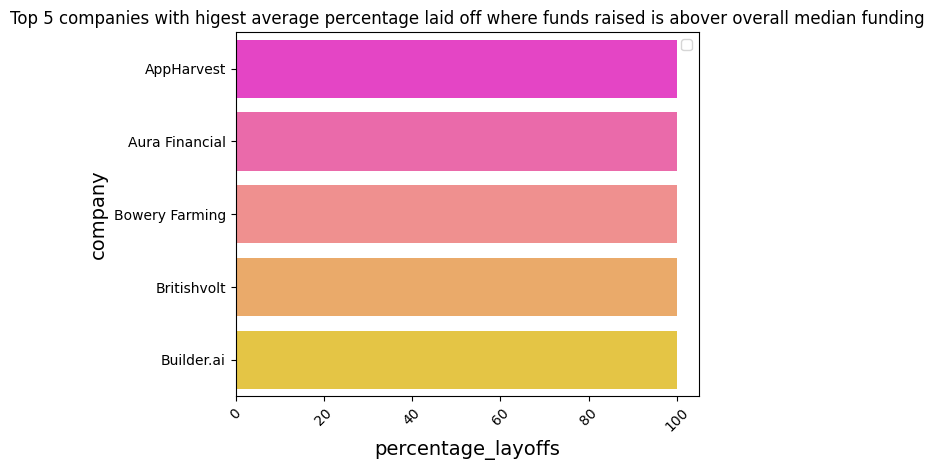

In [9]:
query=""" 
select fra from layoffss
""" 
cur.execute(query)
data=cur.fetchall()
columns = [col[0] for col in cur.description]
df = pd.DataFrame(data, columns=columns)
median = df.fra.median()
query=f""" 
select com as company,100.0*avg(plo) as percentage_layoffs from layoffss
where fra>{median}
group by com
order by avg(plo) desc,com
limit 5
""" 
cur.execute(query)
data=cur.fetchall()
columns = [col[0] for col in cur.description];df = pd.DataFrame(data, columns=columns);
display(df.head().style.hide(axis="index").set_properties(**{'text-align': 'left'}).set_table_styles([{'selector': 'th', 'props': [('text-align', 'center')]},{'selector': 'th', 'props': [('border', '1.5px solid white')]},{'selector': 'td', 'props': [('border', '1px solid white')]}]))
sea.barplot(data=df,x="percentage_layoffs",y="company",palette="spring",errorbar=("ci",0))
mp.xlabel("percentage_layoffs",fontsize=14,rotation=0)
mp.ylabel("company",fontsize=14,rotation=90)
mp.title("Top 5 companies with higest average percentage laid off where funds raised is abover overall median funding")
mp.xticks(rotation=45)
mp.yticks(rotation=0)
mp.legend(loc=1,bbox_to_anchor=(1,1,0,0),ncols=2,labelspacing=1)
mp.tight_layout()
mp.show()


fundings,layoffs,company
Higher Funding,18.970000,1067
Lower Funding,37.890000,1892


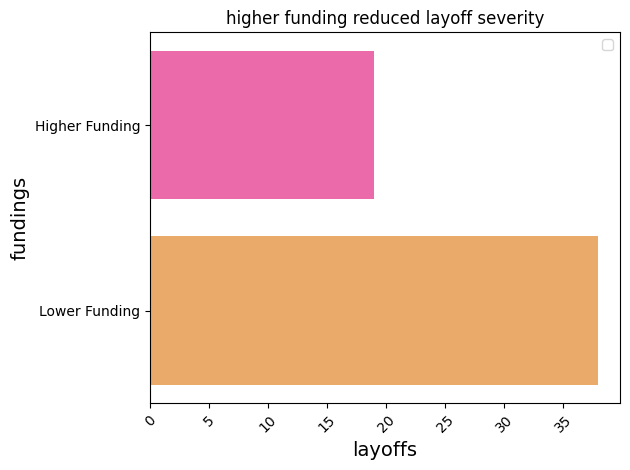

In [10]:
query=f""" 
select 
case
when fra>{median} then "Higher Funding"
else "Lower Funding"
end as fundings,
round(100.0*avg(plo),2) as layoffs,
count(distinct com) as company
from layoffss
group by fundings
"""
cur.execute(query)
data=cur.fetchall()
columns = [col[0] for col in cur.description]
df = pd.DataFrame(data, columns=columns)
display(df.head().style.hide(axis="index").set_properties(**{'text-align': 'left'}).set_table_styles([{'selector': 'th', 'props': [('text-align', 'center')]},{'selector': 'th', 'props': [('border', '1.5px solid white')]},{'selector': 'td', 'props': [('border', '1px solid white')]}]))
sea.barplot(data=df,x="layoffs",y="fundings",palette="spring",errorbar=("ci",0))
mp.xlabel("layoffs",fontsize=14,rotation=0)
mp.ylabel("fundings",fontsize=14,rotation=90)
mp.title("higher funding reduced layoff severity")
mp.xticks(rotation=45)
mp.yticks(rotation=0)
mp.legend(loc=1,bbox_to_anchor=(1,1,0,0),ncols=2,labelspacing=1)
mp.tight_layout()
mp.show()


#### 2. Identify industries where companies had high `total_laid_off` even when `percentage_laid_off` was low, and explain what this indicates about company size.

industry,records
Transportation,15
Food,15
Retail,13
Finance,12
Consumer,11


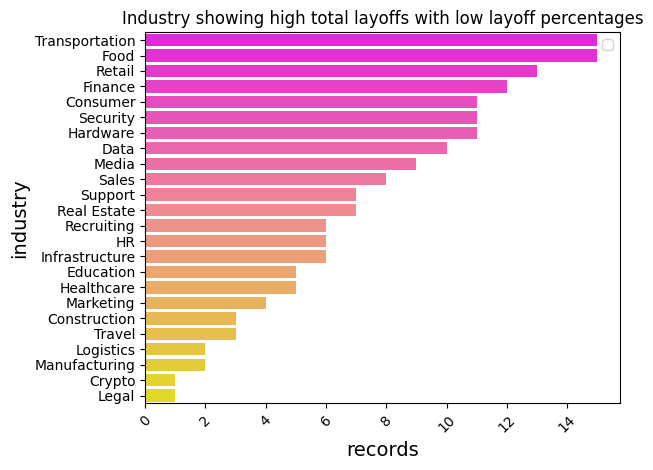

In [11]:
query=""" 
with a as (
select ind,tlo,plo,
ntile(3) over(order by tlo asc) as tlos,
ntile(3) over(order by plo asc) as plos
from layoffss
where tlo_in=1 and plo_in=1
)
select ind as industry,count(*) as records
from a
where tlos=3 and plos=1 and ind!="Other"
group by ind
order by records desc
"""
cur.execute(query)
data=cur.fetchall()
columns = [col[0] for col in cur.description]
df = pd.DataFrame(data, columns=columns)
display(df.head().style.hide(axis="index").set_properties(**{'text-align': 'left'}).set_table_styles([{'selector': 'th', 'props': [('text-align', 'center')]},{'selector': 'th', 'props': [('border', '1.5px solid white')]},{'selector': 'td', 'props': [('border', '1px solid white')]}]))
sea.barplot(data=df,x="records",y="industry",palette="spring",errorbar=("ci",0))
mp.xlabel("records",fontsize=14,rotation=0)
mp.ylabel("industry",fontsize=14,rotation=90)
mp.title("Industry showing high total layoffs with low layoff percentages")
mp.xticks(rotation=45)
mp.yticks(rotation=0)
mp.legend(loc=1,bbox_to_anchor=(1,1,0,0),ncols=2,labelspacing=1)
mp.tight_layout()
mp.show()



#### 3. Analyze monthly layoff trends using `date` and determine which stage (`stage`) was most affected during economic downturn periods.

stage,layoffs,average_percentage
Post-IPO,473923.000000,15.070000
Acquired,41302.000000,30.310000
Series B,24689.000000,31.580000
Series C,19129.000000,23.360000
Series D,17344.000000,18.030000


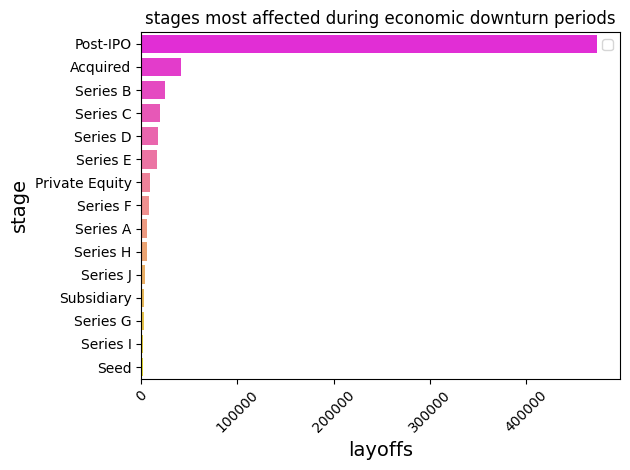

In [12]:
query=f""" 
with monthly as (
select extract(year_month from dat) as months,sum(tlo) as tloss
from layoffss
group by 1
),surge as (
select months from monthly
where tloss>(select avg(tloss) from monthly)
)
select sta as stage,sum(tlo) as layoffs ,round(100.0*avg(plo),2) as average_percentage
from layoffss
where extract(year_month from dat) in (select months from surge) and sta_in=1
group by sta
order by layoffs desc
"""
cur.execute(query)
data=cur.fetchall()
columns = [col[0] for col in cur.description]
df = pd.DataFrame(data, columns=columns)
display(df.head().style.hide(axis="index").set_properties(**{'text-align': 'left'}).set_table_styles([{'selector': 'th', 'props': [('text-align', 'center')]},{'selector': 'th', 'props': [('border', '1.5px solid white')]},{'selector': 'td', 'props': [('border', '1px solid white')]}]))
sea.barplot(data=df,x="layoffs",y="stage",palette="spring",errorbar=("ci",0))
mp.xlabel("layoffs",fontsize=14,rotation=0)
mp.ylabel("stage",fontsize=14,rotation=90)
mp.title("stages most affected during economic downturn periods")
mp.xticks(rotation=45)
mp.yticks(rotation=0)
mp.legend(loc=1,bbox_to_anchor=(1,1,0,0),ncols=2,labelspacing=1)
mp.tight_layout()
mp.show()


In [13]:
query=""" 
with a as (
select extract(year_month from dat),sum(tlo) as tlos
from layoffss
group by 1)
select avg(tlos)
from a
"""
cur.execute(query)
data=cur.fetchall()
columns = [col[0] for col in cur.description]
df = pd.DataFrame(data, columns=columns)
average=df.iloc[0,0]
query=f""" 
with a as (
select extract(year_month from dat) as years,sum(tlo) as tlos
from layoffss
group by years
having sum(tlo)>{average}
)
select sta,sum(tlo) as tloss
from layoffss
where 
extract(year_month from dat) in (select years from a) and sta_in=1
group by sta
order by tloss desc
"""
cur.execute(query)
data=cur.fetchall()
columns = [col[0] for col in cur.description]
df = pd.DataFrame(data, columns=columns)
display(df.head().style.hide(axis="index").set_properties(**{'text-align': 'left'}).set_table_styles([{'selector': 'th', 'props': [('text-align', 'center')]},{'selector': 'th', 'props': [('border', '1.5px solid white')]},{'selector': 'td', 'props': [('border', '1px solid white')]}]))


sta,tloss
Post-IPO,473923.000000
Acquired,41302.000000
Series B,24689.000000
Series C,19129.000000
Series D,17344.000000


#### 4. Compare countries by average layoffs per company and detect which country had the highest concentration of layoffs from late-stage startups.

country,impact_per_company,late_stage,layoffs,late_stage_concentration
Belgium,50.000000,50.000000,50.000000,100.000000
Egypt,58.000000,58.000000,58.000000,100.000000
Finland,160.000000,320.000000,320.000000,100.000000
Ghana,150.000000,150.000000,150.000000,100.000000
Lithuania,60.000000,60.000000,60.000000,100.000000


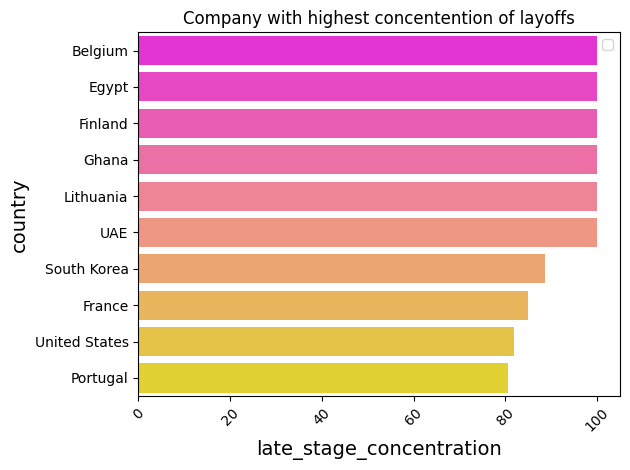

In [14]:
query=""" 
select cou as country,avg(tlo) as impact_per_company,
sum(
case
when sta in ('Series C','Series D','Series E','Post-IPO') then tlo
else 0
end 
) as late_stage,
sum(tlo) as layoffs,
round(
100.0*
sum(
case
when sta in ('Series C','Series D','Series E','Post-IPO') then tlo
else 0
end 
)/sum(tlo),2) as late_stage_concentration 
from layoffss
group by cou
order by late_stage_concentration desc
"""
cur.execute(query)
data=cur.fetchall()
columns = [col[0] for col in cur.description]
df = pd.DataFrame(data, columns=columns)
display(df.head().style.hide(axis="index").set_properties(**{'text-align': 'left'}).set_table_styles([{'selector': 'th', 'props': [('text-align', 'center')]},{'selector': 'th', 'props': [('border', '1.5px solid white')]},{'selector': 'td', 'props': [('border', '1px solid white')]}]))
df=df.head(10)
sea.barplot(data=df,x="late_stage_concentration",y="country",palette="spring",errorbar=("ci",0))
mp.xlabel("late_stage_concentration",fontsize=14,rotation=0)
mp.ylabel("country",fontsize=14,rotation=90)
mp.title("Company with highest concentention of layoffs")
mp.xticks(rotation=45)
mp.yticks(rotation=0)
mp.legend(loc=1,bbox_to_anchor=(1,1,0,0),ncols=2,labelspacing=1)
mp.tight_layout()
mp.show()


#### 5. Detect companies with repeated layoffs over time and calculate whether each new layoff round became larger or smaller than the previous one.

company,date,layoffs,prev_layoffs,change_in_layoffs,trend
100 Thieves,2022-07-13 00:00:00,12.000000,nan,nan,Same
23andMe,2023-08-08 00:00:00,71.000000,75.000000,-4.000000,Decrease
23andMe,2023-06-09 00:00:00,75.000000,nan,nan,Same
23andMe,2024-11-11 00:00:00,200.000000,71.000000,129.000000,Increase
2TM,2022-09-01 00:00:00,100.000000,90.000000,10.000000,Increase


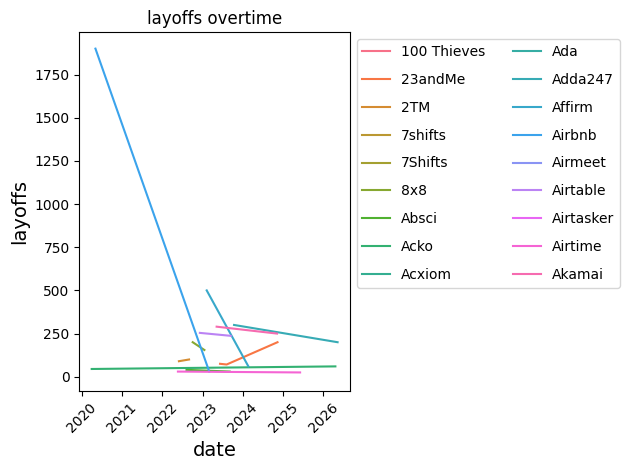

In [15]:
query=""" 
with a as (
SELECT 
com,
dat,
tlo,
LAG(tlo) OVER (PARTITION BY com ORDER BY dat) AS prev_layoffs,
tlo - LAG(tlo) OVER (PARTITION BY com ORDER BY dat) AS change_in_layoffs,
CASE 
WHEN tlo > LAG(tlo) OVER (PARTITION BY com ORDER BY dat) THEN 'Increase'
WHEN tlo < LAG(tlo) OVER (PARTITION BY com ORDER BY dat) THEN 'Decrease'
ELSE 'Same'
END AS trend
FROM layoffss
where tlo_in=1
),b as (
select com,count(*)
from layoffss
group by com 
having count(*)>1
)
select a.com as company,a.dat as date,a.tlo as layoffs,prev_layoffs,change_in_layoffs,trend from a 
join b on a.com=b.com
order by company
"""
cur.execute(query)
data=cur.fetchall()
columns = [col[0] for col in cur.description]
df = pd.DataFrame(data, columns=columns)
display(df.head().style.hide(axis="index").set_properties(**{'text-align': 'left'}).set_table_styles([{'selector': 'th', 'props': [('text-align', 'center')]},{'selector': 'th', 'props': [('border', '1.5px solid white')]},{'selector': 'td', 'props': [('border', '1px solid white')]}]))
df=df.head(30)
sea.lineplot(data=df,x="date",y="layoffs",hue="company")
mp.xlabel("date",fontsize=14,rotation=0)
mp.ylabel("layoffs",fontsize=14,rotation=90)
mp.title("layoffs overtime")
mp.xticks(rotation=45)
mp.yticks(rotation=0)
mp.legend(loc=2,bbox_to_anchor=(1,1,0,0),ncols=2,labelspacing=1)
mp.tight_layout()
mp.show()


#### 6. Find whether missing values (`industry_isnull`, `source_isnull`, `funds_raised_isnull`) are randomly distributed or concentrated in specific countries or industries.

country,industry_null
Germany,0.75188
United States,0.03584
Israel,0.00000
Norway,0.00000
Ireland,0.00000


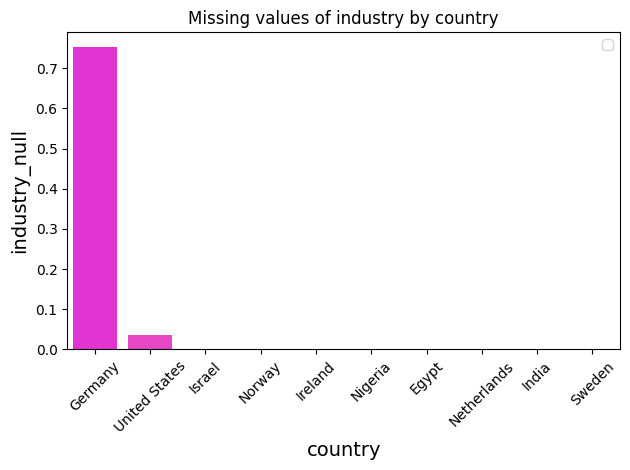

In [16]:
query=""" 
select cou as country,100.0*
sum(
case
when ind_in=0 then 1
else 0
end
)/count(*) industry_null from layoffss
group by cou
order by industry_null desc
"""
cur.execute(query)
data=cur.fetchall()
columns = [col[0] for col in cur.description]
df = pd.DataFrame(data, columns=columns)
display(df.head().style.hide(axis="index").set_properties(**{'text-align': 'left'}).set_table_styles([{'selector': 'th', 'props': [('text-align', 'center')]},{'selector': 'th', 'props': [('border', '1.5px solid white')]},{'selector': 'td', 'props': [('border', '1px solid white')]}]))
df=df.head(10)
sea.barplot(data=df,x="country",y="industry_null",palette="spring",errorbar=("ci",0))
mp.xlabel("country",fontsize=14,rotation=0)
mp.ylabel("industry_null",fontsize=14,rotation=90)
mp.title("Missing values of industry by country")
mp.xticks(rotation=45)
mp.yticks(rotation=0)
mp.legend(loc=1,bbox_to_anchor=(1,1,0,0),ncols=2,labelspacing=1)
mp.tight_layout()
mp.show()


#### 7. Build a risk score for companies using `percentage_laid_off`, `funds_raised`, and `stage`, then rank the most financially unstable companies.

com,plo,fra,sta,layoff_risk,funding_risk,stage_risk,risk
Actyv.ai,0.600000,12.000000,Seed,4,4,4,100.00
Akudo,1.000000,4.000000,Seed,4,4,4,100.00
Alza,1.000000,7.000000,Seed,4,4,4,100.00
Amicole,1.000000,5.000000,Seed,4,4,4,100.00
Anar,1.000000,6.000000,Seed,4,4,4,100.00


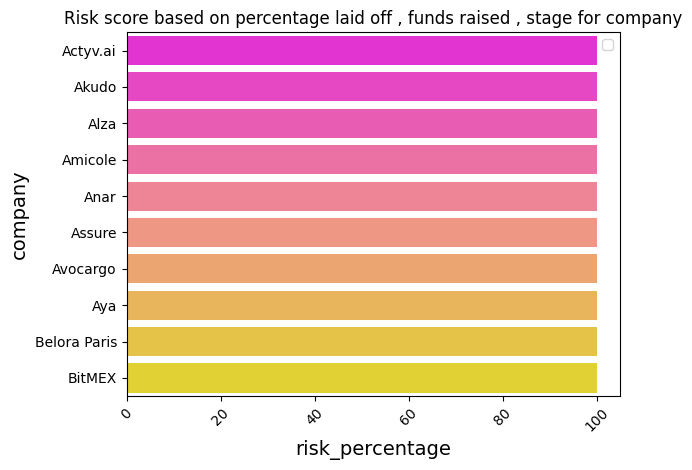

In [17]:
query=""" 
with a as (
select  com,plo,fra,sta,
ntile(4) over(order by plo asc) as layoff_risk,
ntile(4) over(order by fra desc) as funding_risk,
case
when sta='Seed' then 4
when sta='Series A' then 3
when sta='Series B' then 2
when sta='Series C' then 1
when sta='IPO' then 0
else 2
end as stage_risk 
from layoffss
)
select *,round(100.0*(layoff_risk+funding_risk+stage_risk)/12,2) as risk from a
order by risk desc,com
"""
cur.execute(query)
data=cur.fetchall()
columns = [col[0] for col in cur.description]
df = pd.DataFrame(data, columns=columns)
df=df.head(10)
display(df.head().style.hide(axis="index").set_properties(**{'text-align': 'left'}).set_table_styles([{'selector': 'th', 'props': [('text-align', 'center')]},{'selector': 'th', 'props': [('border', '1.5px solid white')]},{'selector': 'td', 'props': [('border', '1px solid white')]}]))
sea.barplot(data=df,x="risk",y="com",palette="spring",errorbar=("ci",0))
mp.xlabel("risk_percentage",fontsize=14,rotation=0)
mp.ylabel("company",fontsize=14,rotation=90)
mp.title("Risk score based on percentage laid off , funds raised , stage for company")
mp.xticks(rotation=45)
mp.yticks(rotation=0)
mp.legend(loc=1,bbox_to_anchor=(1,1,0,0),ncols=2,labelspacing=1)
mp.tight_layout()
mp.show()


#### 8. Determine whether companies with higher funding had lower chances of full layoffs (`percentage_laid_off = 100`) compared to low-funded companies.

fundings,count(*),full_layoffs,percentage_full_layoffs
Low Funding,2209,299,13.54
High Funding,2209,49,2.22


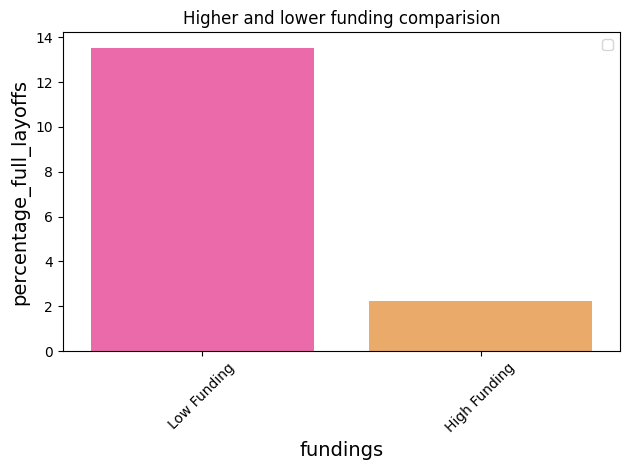

In [18]:
query=""" 
with a as (
select com,plo,fra, 
ntile(2) over(order by fra asc) as funding 
from layoffss)
,b as (
select com,plo,fra,
case
when funding=1 then "Low Funding"
when funding=2 then "High Funding"
end as fundings
from a
)
select fundings,count(*),
sum(
case
when plo=1 then 1
else 0
end
) as full_layoffs,
round(100.0*sum(
case
when plo=1 then 1
else 0
end
)/count(*),2) as percentage_full_layoffs
from b 
group by fundings
"""
cur.execute(query)
data=cur.fetchall()
columns = [col[0] for col in cur.description]
df = pd.DataFrame(data, columns=columns)
display(df.head().style.hide(axis="index").set_properties(**{'text-align': 'left'}).set_table_styles([{'selector': 'th', 'props': [('text-align', 'center')]},{'selector': 'th', 'props': [('border', '1.5px solid white')]},{'selector': 'td', 'props': [('border', '1px solid white')]}]))
sea.barplot(data=df,x="fundings",y="percentage_full_layoffs",palette="spring",errorbar=("ci",0))
mp.xlabel("fundings",fontsize=14,rotation=0)
mp.ylabel("percentage_full_layoffs",fontsize=14,rotation=90)
mp.title("Higher and lower funding comparision")
mp.xticks(rotation=45)
mp.yticks(rotation=0)
mp.legend(loc=1,bbox_to_anchor=(1,1,0,0),ncols=2,labelspacing=1)
mp.tight_layout()
mp.show()


#### 9. Analyze which industries experienced the fastest increase in layoffs year-over-year and identify whether those increases were driven by a few large companies or many smaller ones.

In [19]:
query=f""" 
with yearly as (
select ind,com,extract(year from dat) as year,sum(tlo) as layoffs
from layoffss
group by ind,com,year
),industry_yearly as (
select ind,year,sum(layoffs) as total_layoffs
from yearly
group by ind,year
),yoy as (
select ind,year,total_layoffs,
lag(total_layoffs) over(partition by ind order by year) as prev_layoffs,
total_layoffs-lag(total_layoffs) over(partition by ind order by year) as yoy_change
from industry_yearly
),company_level as (
select ind,com,sum(tlo) as company_layoffs 
from layoffss
group by ind,com
),contribution as (
select ind,sum(company_layoffs) as industry_total,
max(company_layoffs) as max_company_layoffs
from company_level
group by ind
),year_over_year as (
select y.ind,y.year,y.yoy_change,industry_total,max_company_layoffs,
round((1.0*c.max_company_layoffs/c.industry_total),2) as concentration_ratio,
case
when (1.0*c.max_company_layoffs/c.industry_total)>=0.5 then "Few Large Companies"
else "Many Small Companies"
end as driver_type
from yoy y 
join contribution c 
on y.ind=c.ind 
order by y.yoy_change desc
),ranked as (
select *,
row_number() over(partition by ind order by yoy_change desc) as drank
from year_over_year
)
select * from ranked 
where drank=1 and ind!="Other"
order by yoy_change desc
"""
cur.execute(query)
data=cur.fetchall()
columns = [col[0] for col in cur.description]
df = pd.DataFrame(data, columns=columns)
display(df.head().style.format(lambda x: f"{x:.2f}" if isinstance(x, float) else x).hide(axis="index").set_properties(**{'text-align': 'left'}).set_table_styles([{'selector': 'th', 'props': [('text-align', 'center')]},{'selector': 'th', 'props': [('border', '1.5px solid white')]},{'selector': 'td', 'props': [('border', '1px solid white')]}]))


ind,year,yoy_change,industry_total,max_company_layoffs,concentration_ratio,driver_type,drank
Hardware,2023,20854.00,106157.00,43115.00,0.41,Many Small Companies,1
Retail,2022,20126.00,106306.00,58124.00,0.55,Few Large Companies,1
Consumer,2022,16256.00,96712.00,35700.00,0.37,Many Small Companies,1
Transportation,2022,15867.00,66002.00,14500.00,0.22,Many Small Companies,1
Healthcare,2022,13933.00,39244.00,10000.00,0.25,Many Small Companies,1


#### 10. Create a survival-style analysis where you estimate which startup stages were most likely to experience layoffs after raising large amounts of funding.

stage,high_funded_companies,high_funded_companies_layoffs,layoffs_probability
Series B,11,11,100.00
Series J,11,10,90.91
Series I,8,7,87.50
Series H,34,29,85.29
Acquired,36,29,80.56


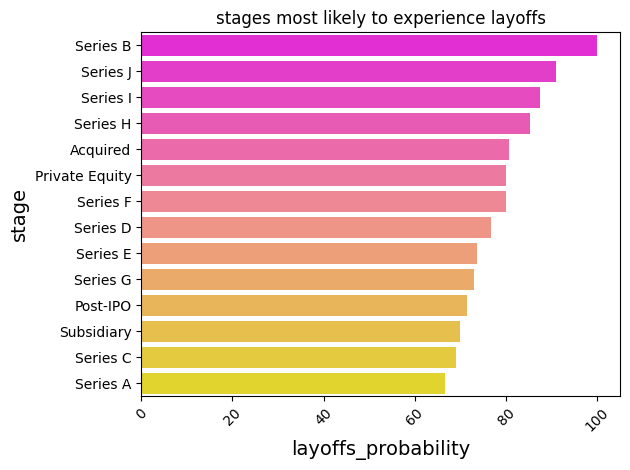

In [20]:
query=""" 
with funds as (
select sta,fra,tlo,tlo_in, 
ntile(4) over(order by fra desc) as funding_group 
from layoffss
where sta_in=1
)
,highest_funding as (
select sta, 
sum(case
when funding_group=1 then 1
else 0
end 
) as high_funded_companies,
sum(case
when funding_group=1 and tlo_in=1 then 1
else 0
end 
) as high_funded_companies_layoffs
from funds
group by sta
)
select sta as stage, high_funded_companies , high_funded_companies_layoffs,
100.0*high_funded_companies_layoffs/high_funded_companies as layoffs_probability
from highest_funding
where high_funded_companies>0
order by layoffs_probability desc
"""
cur.execute(query)
data=cur.fetchall()
columns = [col[0] for col in cur.description]
df = pd.DataFrame(data, columns=columns)
cols = ["layoffs_probability"]
df[cols] = df[cols].apply(pd.to_numeric)
display(df.head().style.format(lambda x: f"{x:.2f}" if isinstance(x, float) else x).hide(axis="index").set_properties(**{'text-align': 'left'}).set_table_styles([{'selector': 'th', 'props': [('text-align', 'center')]},{'selector': 'th', 'props': [('border', '1.5px solid white')]},{'selector': 'td', 'props': [('border', '1px solid white')]}]))
sea.barplot(data=df,x="layoffs_probability",y="stage",palette="spring",errorbar=("ci",0))
mp.xlabel("layoffs_probability",fontsize=14,rotation=0)
mp.ylabel("stage",fontsize=14,rotation=90)
mp.title("stages most likely to experience layoffs")
mp.xticks(rotation=45)
mp.yticks(rotation=0)
mp.tight_layout()
mp.show()



In [21]:
query=""" 
with funds as (
select sta,fra,tlo,tlo_in, 
ntile(4) over(order by fra desc) as highest_funding 
from layoffss
where sta_in=1
)

,highest_funding as (
select sta,tlo,fra,
case
when highest_funding=1 then "Yes"
else "No"
end as highest_fundings
from funds
),highest_fundings_only as (
select sta,
sum(
case
when highest_fundings="Yes" then 1
else 0
end 
) as highest_funding
from highest_funding
group by sta
)

,highest_funding_layoffs as (
select sta,tlo,fra,
case
when highest_funding=1 then "Yes"
else "No"
end as highest_fundings
from funds
where tlo_in=1
)
, highest_funding_layoffss as (
select sta,
sum(
case
when highest_fundings="Yes" then 1
else 0
end 
) as highest_funding
from highest_funding_layoffs
group by sta
)

select hfo.sta as stage,hfo.highest_funding as highest_funding_only,hfl.highest_funding as highest_funding_layoffs,
100.0*hfl.highest_funding/hfo.highest_funding as layoffs_probability
from highest_fundings_only hfo
join highest_funding_layoffss hfl using(sta)
order by layoffs_probability desc
"""
cur.execute(query)
data=cur.fetchall()
columns = [col[0] for col in cur.description]
df = pd.DataFrame(data, columns=columns)
cols = ["layoffs_probability"]
df[cols] = df[cols].apply(pd.to_numeric)
display(df.head().style.format(lambda x: f"{x:.2f}" if isinstance(x, float) else x).hide(axis="index").set_properties(**{'text-align': 'left'}).set_table_styles([{'selector': 'th', 'props': [('text-align', 'center')]},{'selector': 'th', 'props': [('border', '1.5px solid white')]},{'selector': 'td', 'props': [('border', '1px solid white')]}]))


stage,highest_funding_only,highest_funding_layoffs,layoffs_probability
Series B,11,11,100.00
Series J,11,10,90.91
Series I,8,7,87.50
Series H,34,29,85.29
Acquired,36,29,80.56
